In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,  classification_report
)

In [4]:
spy  = pd.read_csv('../data/SPY_features.csv',  parse_dates=['date'], index_col='date').sort_index()

In [5]:
spy.head()

,adj_close,close,high,low,open,volume,daily_return,weekly_return,ma_7,ma_21,...,lag_return_5,month,quarter,season_num,season,is_earnings_week,vix,is_major_event,target_direction,target_return
date,,,,,,,,,,,,,,,,,,,,,
2015-01-02,170.125015,205.429993,206.880005,204.179993,206.380005,121465900,-0.000535,-0.011262,171.691376,169.676133,...,0.000096,1,1,0,Winter,0,17.790001,0,0,-0.005744
2015-01-05,167.052658,201.720001,204.369995,201.350006,204.169998,169632600,-0.018059,-0.032239,170.977999,169.477819,...,0.003225,1,1,0,Winter,0,19.920000,0,0,0.004610
2015-01-06,165.479141,199.820007,202.720001,198.860001,202.089996,209151400,-0.009419,-0.042641,170.037469,169.213594,...,0.001344,1,1,0,Winter,0,21.120001,0,1,0.011310
2015-01-07,167.541260,202.309998,202.720001,200.880005,201.419998,125346700,0.012462,-0.025481,169.312267,169.034233,...,-0.005366,1,1,0,Winter,0,19.309999,0,1,-0.007167
2015-01-08,170.514206,205.899994,206.160004,203.990005,204.009995,147217800,0.017745,0.001751,168.978638,169.050955,...,-0.009923,1,1,0,Winter,0,17.010000,0,0,-0.033414


In [6]:
FEATURES = [
    'daily_return', 'weekly_return', 'ma_cross', 'dist_from_ma21', 'daily_range',
    'rsi_14', 'macd_hist', 'bb_position', 'volatility_7', 'volatility_20',
    'volume_change', 'volume_ratio',
    'lag_return_1', 'lag_return_3', 'lag_return_5', 'vix'
]

TARGET_CLS = 'target_direction'

In [7]:
spy_cls  = spy[FEATURES + [TARGET_CLS]].dropna().copy()

print(spy_cls.shape)

(2515, 17)


In [8]:
def walk_forward_splits(df, train_window, test_window=42, embargo=5):
    """
    Generates (train_idx, test_idx) pairs for walk-forward validation.
    embargo = gap between train end and test start to prevent leakage
    from lagged features (lag_return_5, weekly_return, volatility_20 etc.)
    
    Fold 1: Train [0 → 62]  Gap [63 → 67]  Test [68 → 109]
    Fold 2: Train [42 → 104] Gap [105 → 109] Test [110 → 151]
    """
    splits = []
    n = len(df)
    start = 0

    while start + train_window + embargo + test_window <= n:
        train_start = start
        train_end   = start + train_window

        test_start  = train_end + embargo
        test_end    = test_start + test_window

        train_idx = list(range(train_start, train_end))
        test_idx  = list(range(test_start, test_end))

        splits.append((train_idx, test_idx))

        # move forward by test window
        start += test_window

    return splits



In [9]:
spy_folds = walk_forward_splits(spy_cls, train_window = 189)
print("SPY folds:", len(spy_folds))

SPY folds: 55


In [10]:
fold_scores = []
spy_actual, spy_pred = [], []
spy_probs = []

In [11]:
all_importances = []

In [12]:
print(f"Starting Walk-Forward Validation with {len(spy_folds)} folds...")
for i, (train_idx, test_idx) in enumerate(spy_folds):
    X_train = spy_cls.iloc[train_idx][FEATURES]
    y_train = spy_cls.iloc[train_idx][TARGET_CLS]
    X_test  = spy_cls.iloc[test_idx][FEATURES]
    y_test  = spy_cls.iloc[test_idx][TARGET_CLS]

    rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
    rf.fit(X_train, y_train)

   
    y_p = rf.predict(X_test)
    y_prob = rf.predict_proba(X_test)[:, 1]

   
    cm = confusion_matrix(y_test, y_p, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0

    fold_scores.append({
        'accuracy': accuracy_score(y_test, y_p),
        'f1': f1_score(y_test, y_p, zero_division=0),
        'precision': precision_score(y_test, y_p, zero_division=0),
        'recall': recall_score(y_test, y_p, zero_division=0),
        'specificity': spec
    })

    spy_actual.extend(y_test)
    spy_pred.extend(y_p)
    spy_probs.extend(y_prob)
    all_importances.append(rf.feature_importances_)

Starting Walk-Forward Validation with 55 folds...


In [13]:
results_df = pd.DataFrame(fold_scores)
results_df

,accuracy,f1,precision,recall,specificity
0,0.547619,0.512821,0.454545,0.588235,0.520000
1,0.547619,0.666667,0.527778,0.904762,0.190476
2,0.547619,0.512821,0.714286,0.400000,0.764706
3,0.547619,0.424242,0.777778,0.291667,0.888889
4,0.476190,0.450000,0.529412,0.391304,0.578947
5,0.642857,0.693878,0.607143,0.809524,0.476190
6,0.571429,0.653846,0.607143,0.708333,0.388889
7,0.476190,0.266667,0.500000,0.181818,0.800000
8,0.571429,0.526316,0.625000,0.454545,0.700000
9,0.500000,0.322581,0.500000,0.238095,0.761905


In [14]:

prob_df = pd.DataFrame({
    'actual': spy_actual,
    'prob_up': spy_probs

})

high_conviction_up = prob_df[prob_df['prob_up'] > 0.55]
high_conviction_down = prob_df[prob_df['prob_up'] < 0.45]

acc_up = (high_conviction_up['actual'] == 1).mean()
acc_down = (high_conviction_down['actual'] == 0).mean()

print(f"Accuracy when Prob > 0.55 (UP): {acc_up:.4f} (Samples: {len(high_conviction_up)})")
print(f"Accuracy when Prob < 0.45 (DOWN): {acc_down:.4f} (Samples: {len(high_conviction_down)})")

Accuracy when Prob > 0.55 (UP): 0.5608 (Samples: 1045)
Accuracy when Prob < 0.45 (DOWN): 0.4628 (Samples: 592)


In [15]:
results_df.describe()

,accuracy,f1,precision,recall,specificity
count,55.000000,55.000000,55.000000,55.000000,55.000000
mean,0.510390,0.545852,0.554147,0.588669,0.413196
std,0.080646,0.142827,0.121283,0.222892,0.232113
min,0.333333,0.074074,0.200000,0.045455,0.062500
25%,0.476190,0.473389,0.478778,0.424812,0.231283
50%,0.523810,0.555556,0.562500,0.600000,0.409091
75%,0.571429,0.654545,0.640762,0.755952,0.539706
max,0.642857,0.776119,0.800000,1.000000,0.944444


In [16]:
avg_importance = np.mean(all_importances, axis=0)
feat_imp = pd.Series(avg_importance, index=FEATURES).sort_values(ascending=False)
feat_imp

lag_return_3      0.073506
lag_return_5      0.072021
volume_change     0.069921
daily_range       0.067209
daily_return      0.065915
lag_return_1      0.063861
volatility_20     0.063635
volume_ratio      0.062757
weekly_return     0.062743
vix               0.060145
ma_cross          0.059817
volatility_7      0.058331
macd_hist         0.056988
rsi_14            0.055995
dist_from_ma21    0.053773
bb_position       0.053381
dtype: float64

In [17]:
print(classification_report(spy_actual, spy_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.45      0.41      0.43      1038
           1       0.55      0.59      0.57      1272

    accuracy                           0.51      2310
   macro avg       0.50      0.50      0.50      2310
weighted avg       0.51      0.51      0.51      2310



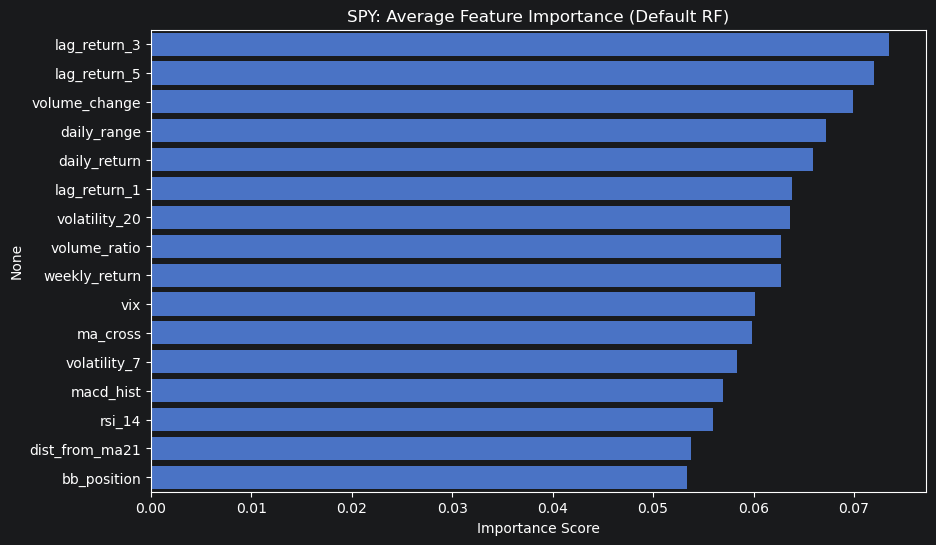

In [18]:
plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.title("SPY: Average Feature Importance (Default RF)")
plt.xlabel("Importance Score")
plt.show()

In [19]:

n_estimators_values  = [100, 200, 500]
max_depth_values     = [4, 6, 8, 10, None]
min_samples_leaf_values = [1, 5, 10, 20]
max_features_values  = ['sqrt', 'log2']

from itertools import product
combos = list(product(n_estimators_values, max_depth_values, min_samples_leaf_values, max_features_values))
print(f'Grid: {len(n_estimators_values)} n_estimators x {len(max_depth_values)} max_depth x {len(min_samples_leaf_values)} min_samples_leaf x {len(max_features_values)} max_features = {len(combos)} combinations')
print(f'Folds per combo: {len(spy_folds)}')
print(f'Total RF fits: {len(combos) * len(spy_folds)}')

Grid: 3 n_estimators x 5 max_depth x 4 min_samples_leaf x 2 max_features = 120 combinations
Folds per combo: 55
Total RF fits: 6600


In [20]:
grid_results = []

for n_est, max_d, min_leaf, max_feat in combos:
    fold_f1s   = []
    fold_accs  = []
    fold_precs = []
    fold_recs  = []
    fold_specs = []

    for train_idx, test_idx in spy_folds:
        X_train = spy_cls.iloc[train_idx][FEATURES]
        y_train = spy_cls.iloc[train_idx][TARGET_CLS]
        X_test  = spy_cls.iloc[test_idx][FEATURES]
        y_test  = spy_cls.iloc[test_idx][TARGET_CLS]

        rf = RandomForestClassifier(
            n_estimators=n_est,
            max_depth=max_d,
            min_samples_leaf=min_leaf,
            max_features=max_feat,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        )
        rf.fit(X_train, y_train)
        y_pred = rf.predict(X_test)

        fold_f1s.append(f1_score(y_test, y_pred, zero_division=0))
        fold_accs.append(accuracy_score(y_test, y_pred))
        fold_precs.append(precision_score(y_test, y_pred, zero_division=0))
        fold_recs.append(recall_score(y_test, y_pred, zero_division=0))

        cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        fold_specs.append(spec)

    grid_results.append({
        'n_estimators':    n_est,
        'max_depth':       max_d,
        'min_samples_leaf': min_leaf,
        'max_features':    max_feat,
        'f1':          np.mean(fold_f1s),
        'accuracy':    np.mean(fold_accs),
        'precision':   np.mean(fold_precs),
        'recall':      np.mean(fold_recs),
        'specificity': np.mean(fold_specs),
    })
    print(f'  n_est={n_est:>3}  depth={str(max_d):<5}  min_leaf={min_leaf:<3}  max_feat={max_feat:<5}  '
          f'F1={np.mean(fold_f1s):.3f}  acc={np.mean(fold_accs):.3f}  '
          f'prec={np.mean(fold_precs):.3f}  rec={np.mean(fold_recs):.3f}  spec={np.mean(fold_specs):.3f}')

rf_grid_df = pd.DataFrame(grid_results)

  n_est=100  depth=4      min_leaf=1    max_feat=sqrt   F1=0.515  acc=0.495  prec=0.548  rec=0.533  spec=0.452
  n_est=100  depth=4      min_leaf=1    max_feat=log2   F1=0.515  acc=0.495  prec=0.548  rec=0.533  spec=0.452
  n_est=100  depth=4      min_leaf=5    max_feat=sqrt   F1=0.510  acc=0.502  prec=0.559  rec=0.519  spec=0.485
  n_est=100  depth=4      min_leaf=5    max_feat=log2   F1=0.510  acc=0.502  prec=0.559  rec=0.519  spec=0.485
  n_est=100  depth=4      min_leaf=10   max_feat=sqrt   F1=0.516  acc=0.508  prec=0.578  rec=0.524  spec=0.500
  n_est=100  depth=4      min_leaf=10   max_feat=log2   F1=0.516  acc=0.508  prec=0.578  rec=0.524  spec=0.500
  n_est=100  depth=4      min_leaf=20   max_feat=sqrt   F1=0.499  acc=0.500  prec=0.565  rec=0.503  spec=0.503
  n_est=100  depth=4      min_leaf=20   max_feat=log2   F1=0.499  acc=0.500  prec=0.565  rec=0.503  spec=0.503
  n_est=100  depth=6      min_leaf=1    max_feat=sqrt   F1=0.544  acc=0.513  prec=0.563  rec=0.573  spec=0.443
 

In [21]:
print('Top 5 by F1:')
print(rf_grid_df.sort_values('f1', ascending=False).head().to_string(index=False))

print('\nTop 5 by Accuracy:')
print(rf_grid_df.sort_values('accuracy', ascending=False).head().to_string(index=False))

print('\nTop 5 by Precision:')
print(rf_grid_df.sort_values('precision', ascending=False).head().to_string(index=False))

print('\nTop 5 by Specificity:')
print(rf_grid_df.sort_values('specificity', ascending=False).head().to_string(index=False))

print('\nCurrent baseline (n_estimators=100):')
baseline = rf_grid_df[
    (rf_grid_df['n_estimators'] == 100) 
]
print(baseline.to_string(index=False))

Top 5 by F1:
 n_estimators  max_depth  min_samples_leaf max_features       f1  accuracy  precision   recall  specificity
          200        8.0                 1         sqrt 0.558838  0.516450   0.561551 0.604537     0.406317
          200        8.0                 1         log2 0.558838  0.516450   0.561551 0.604537     0.406317
          200        NaN                 1         log2 0.558551  0.518615   0.561472 0.607470     0.408671
          200        NaN                 1         sqrt 0.558551  0.518615   0.561472 0.607470     0.408671
          500        8.0                 1         log2 0.557656  0.517749   0.561515 0.603888     0.408566

Top 5 by Accuracy:
 n_estimators  max_depth  min_samples_leaf max_features       f1  accuracy  precision   recall  specificity
          200        NaN                 1         log2 0.558551  0.518615   0.561472 0.607470     0.408671
          200        NaN                 1         sqrt 0.558551  0.518615   0.561472 0.607470     0.40